# Baseline ML: Predicting W3 Mental Health from W2 Features

## Objective
To establish a solid Machine Learning baseline (Linear Regression & Random Forest) that predicts **Wave 3 Mental Health Scores** using **Wave 2 Personal Features**.

## Methodology
1.  **Inputs (X)**: Top 20 correlated personal features from Wave 2 (e.g., Self-esteem, Family, etc.).
2.  **Target (y)**: Mental Health Total Score from Wave 3.
3.  **Preprocessing**: Standardization (Z-score) applied to all features.
4.  **Models**:
    *   Linear Regression (Simple, interpretable).
    *   Random Forest (Non-linear, robust).

This baseline will be compared against GNN models.
---

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import os

# --- Configuration ---
W2_DATA_PATH = r"../../../../Data/2024data/TIGPS_W2_studentdata_ver5_cleaned_mental_common_only.csv"
W3_DATA_PATH = r"../../../../Data/2025data/TIGPS_W3_studentdata_ver4_cleaned_cols_removed_missing_common_only.csv"

# Top 20 Features (Personal variables from W2)
TOP_20_FEATURES = [
    'v51', 'v59_5', 'v52_3', 'v57_4', 'v52_2', 
    'v57_3', 'v50', 'v57_2', 'v52', 'v57_1', 
    'v52_1', 'v57_5', 'v24_2', 'v8_08', 'v28_6', 
    'v39_2', 'v5_5', 'v8_05', 'v24_6', 'v35_2'
]

# Also include W2 Mental Health Score itself (Auto-regressive baseline)
# It's usually the strongest predictor.
MH_ITEMS_W2 = [f"v55_{i}" for i in range(1, 15)]

In [16]:
# 1. Load Data
print("Loading W2 Data...")
w2_df = pd.read_csv(W2_DATA_PATH, on_bad_lines='skip', engine='python')

print("Loading W3 Data...")
try:
    w3_df = pd.read_csv(W3_DATA_PATH, on_bad_lines='skip', engine='python')
except Exception as e:
    print(f"Error loading W3: {e}")

# 2. Process Features (X) from W2
# Calculate W2 MH Total Score
w2_df['w2_mh_score'] = w2_df[MH_ITEMS_W2].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)

# Select Features: Top 20 + W2 MH Score
X_cols = TOP_20_FEATURES + ['w2_mh_score']
X_raw = w2_df[['student_id'] + X_cols].copy()

# 3. Process Target (y) from W3
mh_cols_w3 = [f"54-{i}" for i in range(1, 15)]
w3_df['target_w3'] = w3_df[mh_cols_w3].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
y_raw = w3_df[['student_id', 'target_w3']].dropna()

# 4. Merge W2 features with W3 target
merged = pd.merge(X_raw, y_raw, on='student_id', how='inner')
print(f"Merged Dataset (Students in both W2 & W3): {merged.shape}")

Loading W2 Data...
Loading W3 Data...
Merged Dataset (Students in both W2 & W3): (7175, 23)


In [17]:
# 5. Preprocessing
X = merged[X_cols].apply(pd.to_numeric, errors='coerce')
y = merged['target_w3']

# Impute Missing X (Median)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Standardize X (Z-score) - GOOD PRACTICE
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

print(f"Final Feature Matrix shape: {X_scaled.shape}")

Final Feature Matrix shape: (7175, 21)


In [18]:
# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 6457, Test size: 718


In [19]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    return model

# 1. Linear Regression
lr_model = evaluate(LinearRegression(), "Linear Regression")

# 2. Random Forest
rf_model = evaluate(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest")

--- Linear Regression ---
MSE: 117.1869
MAE: 7.3353
R2 Score: 0.2398
--- Random Forest ---
MSE: 129.9412
MAE: 7.8560
R2 Score: 0.1571


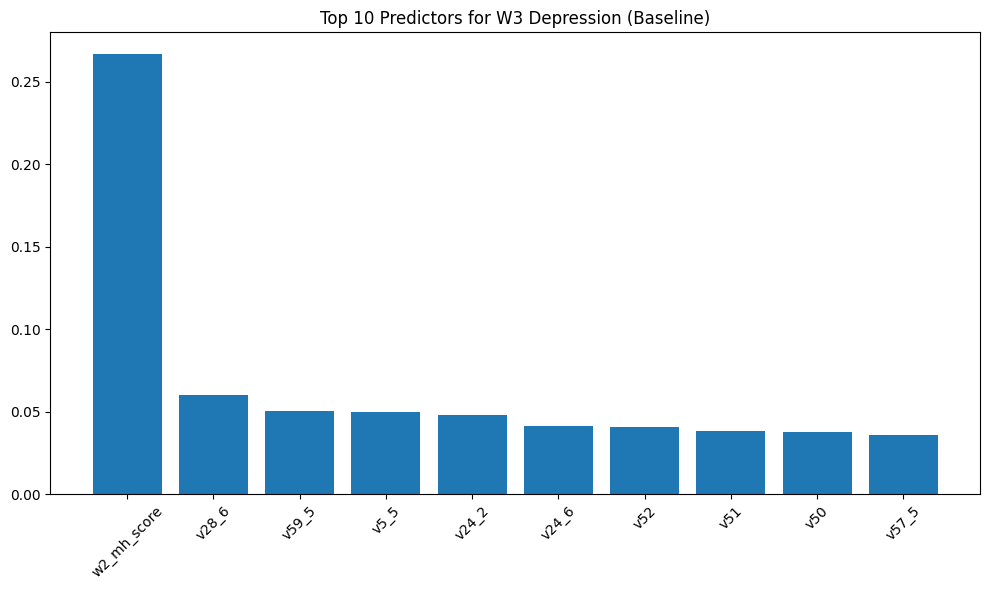

Top 5 Predictors:
w2_mh_score: 0.2667
v28_6: 0.0598
v59_5: 0.0504
v5_5: 0.0497
v24_2: 0.0479


In [20]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Predictors for W3 Depression (Baseline)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X_train.columns[indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

print("Top 5 Predictors:")
for i in range(5):
    print(f"{X_train.columns[indices[i]]}: {importances[indices[i]]:.4f}")